Titan Dataset

Objective:
Learn to identify and fix common data quality issues so a raw dataset is ready for reliable analysis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the dataset


In [ ]:
df = pd.read_csv("/content/train_titanic.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


Understand the dataset

In [ ]:
df.shape

(891, 12)

Check information and data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Gender          object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Check missing values

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Gender,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Check percentage of missing values

In [ ]:

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_table)

,Missing Values,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Gender,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


Handle missing Age

In [ ]:
df["Age"].median()

28.0

In [ ]:
df["Age"]= df["Age"].fillna(df["Age"].median())

In [ ]:
print("Missing Age Value:",df["Age"].isnull().sum())

Missing Age Value: 0


Handle missing Cabin

In [ ]:
df["Cabin_Available"] = df["Cabin"].notnull().astype(int)

In [ ]:
df = df.drop(columns=["Cabin"])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Gender           891 non-null    object 
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Embarked         889 non-null    object 
 11  Cabin_Available  891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


Handle missing Embarked

In [ ]:
print(df["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [ ]:
print("Missing Embarked values:", df["Embarked"].isnull().sum())

Missing Embarked values: 2


Check duplicate rows

In [ ]:
Duplicate_count = df.duplicated().sum()

In [ ]:
print("Number of duplicated Rows",Duplicate_count)

Number of duplicated Rows 0


Check duplicate Passenger IDs

In [ ]:
print("Duplicate Passenger IDs:", df["PassengerId"].duplicated().sum())

Duplicate Passenger IDs: 0


Standardize text data

In [ ]:
text_columns = df.select_dtypes(include="object").columns

print(text_columns)

Index(['Name', 'Gender', 'Ticket', 'Embarked'], dtype='object')


In [ ]:
for col in text_columns:
    df[col] = df[col].str.strip()

Standardize Gender

In [ ]:
print(df["Gender"].unique())

['male' 'female']


In [ ]:
df["Gender"] = df["Gender"].str.strip().str.title()

print(df["Gender"].unique())

['Male' 'Female']


Standardize Embarked

In [ ]:
df["Embarked"] = df["Embarked"].str.strip().str.upper()

print(df["Embarked"].unique())

['S' 'C' 'Q' nan]


Validate numeric columns

In [ ]:
numeric_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

print(df[numeric_columns].dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
dtype: object


In [ ]:
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Check logical values

In [ ]:
print(df["Survived"].unique())

[0 1]


In [ ]:
print(df["Pclass"].unique())

[3 1 2]


In [ ]:
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())

Minimum age: 0.42
Maximum age: 80.0


Check outliers

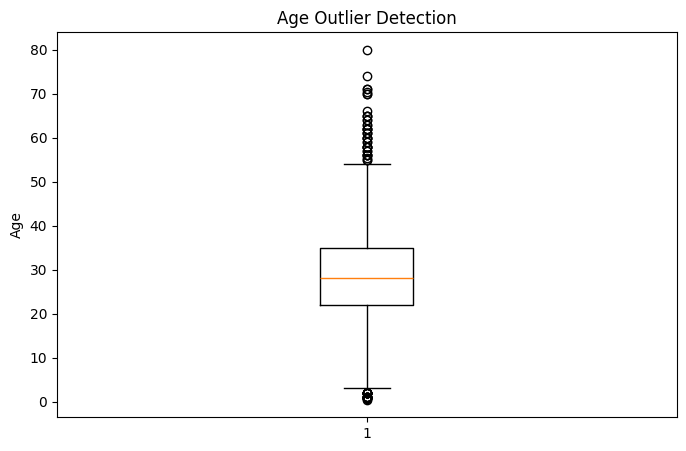

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Age"].dropna())
plt.title("Age Outlier Detection")
plt.ylabel("Age")
plt.show()

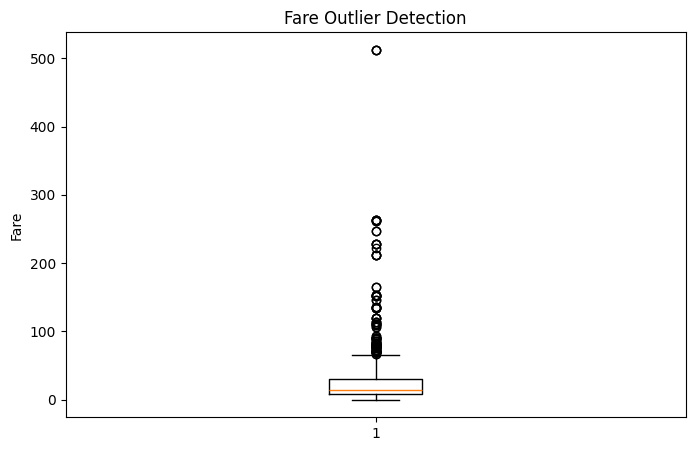

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Fare"].dropna())
plt.title("Fare Outlier Detection")
plt.ylabel("Fare")
plt.show()

Final missing-value validation

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId        0
Survived           0
Pclass             0
Name               0
Gender             0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           2
Cabin_Available    0
dtype: int64


Final duplicate validation

In [ ]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


Final dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Gender           891 non-null    object 
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Embarked         889 non-null    object 
 11  Cabin_Available  891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [ ]:
print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Available
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,S,0


In [ ]:
df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
change_log = pd.DataFrame({
    "Issue": [
        "Missing Age values",
        "Missing Cabin values",
        "Missing Embarked values",
        "Duplicate rows",
        "Text formatting",
        "Data type validation",
        "Outlier detection"
    ],

    "Column": [
        "Age",
        "Cabin",
        "Embarked",
        "All columns",
        "Gender, Embarked, other text columns",
        "Numeric columns",
        "Age, Fare"
    ],

    "Action Taken": [
        "Filled missing values using median",
        "Created Cabin_Available indicator and removed Cabin",
        "Filled missing values using mode",
        "Checked and confirmed no duplicate rows",
        "Removed whitespace and standardized text case",
        "Validated and converted numeric columns",
        "Identified using boxplots; genuine values were retained"
    ],

    "Reason": [
        "Preserves records while reducing the effect of extreme values",
        "Approximately 77% of Cabin values were missing",
        "Only 2 values were missing, so mode was appropriate",
        "No duplicate records were found",
        "Ensures consistent categorical values",
        "Ensures correct numerical analysis",
        "Outliers may represent genuine observations"
    ]
})

display(change_log)

,Issue,Column,Action Taken,Reason
0,Missing Age values,Age,Filled missing values using median,Preserves records while reducing the effect of...
1,Missing Cabin values,Cabin,Created Cabin_Available indicator and removed ...,Approximately 77% of Cabin values were missing
2,Missing Embarked values,Embarked,Filled missing values using mode,"Only 2 values were missing, so mode was approp..."
3,Duplicate rows,All columns,Checked and confirmed no duplicate rows,No duplicate records were found
4,Text formatting,"Gender, Embarked, other text columns",Removed whitespace and standardized text case,Ensures consistent categorical values
5,Data type validation,Numeric columns,Validated and converted numeric columns,Ensures correct numerical analysis
6,Outlier detection,"Age, Fare",Identified using boxplots; genuine values were...,Outliers may represent genuine observations


In [ ]:
change_log.to_excel("change_log.xlsx", index=False)

print("Change log created successfully!")

Change log created successfully!
